In [21]:
# import libraries

import pandas as pd
import numpy as np
!pip install yellowbrick
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
# load data
df = pd.read_csv('/content/Insta_users_behavior.csv')
df.head()

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


In [3]:
# create features and visualize sample data

x = df[['Instagram visit score', 'Spending_rank(0 to 100)']]
x.head()

,Instagram visit score,Spending_rank(0 to 100)
0,63,24.050708
1,61,25.223290
2,104,18.528245
3,82,86.890232
4,14,31.492397


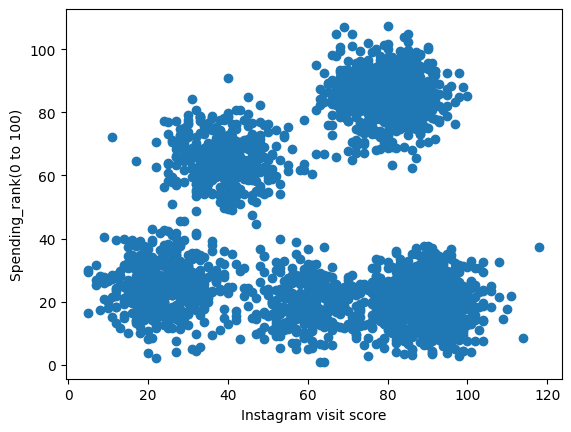

In [4]:
import matplotlib.pyplot as plt

# visualize data

plt.scatter(x['Instagram visit score'],x['Spending_rank(0 to 100)'])
plt.xlabel('Instagram visit score')
plt.ylabel('Spending_rank(0 to 100)')
plt.show()

In [5]:
# count within-cluster Sum of Square

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

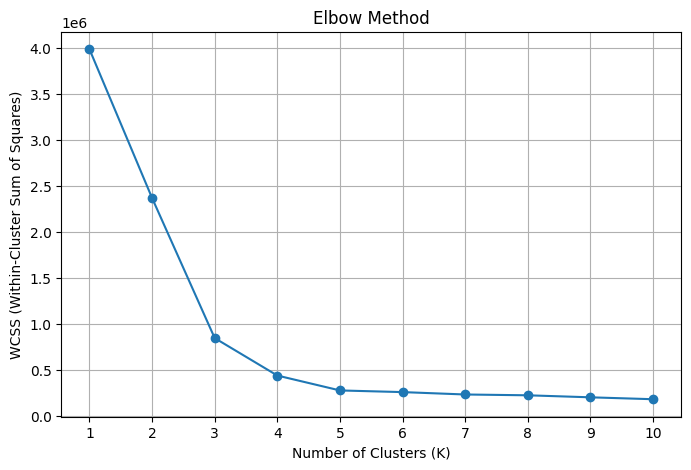

In [16]:
# use Elbow Method

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [7]:
# Train Kmeans Clustering Model

kmeans = KMeans(n_clusters=3, n_init=20, random_state=42)
y_kmeans = kmeans.fit_predict(x)

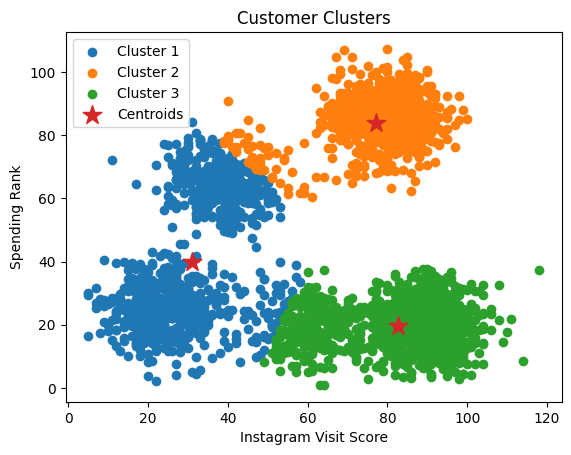

In [17]:
# visualize clusters

plt.scatter(x.iloc[y_kmeans == 0, 0], x.iloc[y_kmeans == 0, 1], label='Cluster 1')
plt.scatter(x.iloc[y_kmeans == 1, 0], x.iloc[y_kmeans == 1, 1], label='Cluster 2')
plt.scatter(x.iloc[y_kmeans == 2, 0], x.iloc[y_kmeans == 2, 1], label='Cluster 3')

plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200,
            marker='*',
            label='Centroids')

plt.xlabel('Instagram Visit Score')
plt.ylabel('Spending Rank')
plt.title('Customer Clusters')
plt.legend()
plt.show()

In [18]:
# evaluate model. calculate Silhouette score

from sklearn.metrics import silhouette_score

score = silhouette_score(x, y_kmeans)

print("Silhouette Score:", score)

Silhouette Score: 0.5954153248201919


In [19]:
# Measuring Davis-Bouldin Index

from sklearn.metrics import davies_bouldin_score

dbi = davies_bouldin_score(x, y_kmeans)

print("Davies-Bouldin Index:", dbi)

Davies-Bouldin Index: 0.5947864710743138


In [20]:
# Calinski–Harabasz Index (CHI)

from sklearn.metrics import calinski_harabasz_score

chi = calinski_harabasz_score(x, y_kmeans)

print("Calinski-Harabasz Index:", chi)

Calinski-Harabasz Index: 4811.543793581932


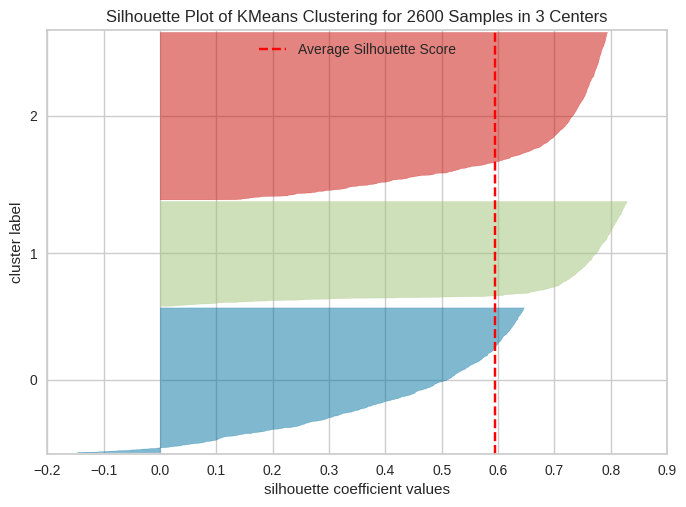

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 2600 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [23]:
# visualizing silhouette score

from yellowbrick.cluster import SilhouetteVisualizer

# Create a new K-Means model
model = KMeans(
    n_clusters=3,
    n_init=20,
    random_state=42
)

# Create the visualizer
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')

# Fit the visualizer
visualizer.fit(x)

# Display the plot
visualizer.show()